# Frequency Estimation and Heavy Hitters
## Executive summary
### 1. Misra-Gries Algorithm (MG)
We implemented the Misra-Gries algorithm closely following the pseudocode provided in the lecture notes. The update function processes the incoming data stream under a strict memory constraint, defined by maxNumCounters. This parameter dictates the maximum number of distinct elements we can track simultaneously. When the dictionary reaches full capacity and a new, unmonitored element arrives, we identify the minimum counter value currently inside the dictionary, subtract this amount from all active counters, and remove any elements whose counts drop to zero. This ensures sufficient space for new elements. Finally, the query function retrieves the estimated frequency of a given element, returning 0 if the element is not currently tracked in our counters.

### 2. Count-Min sketch (CMS)
Similarly, we implemented the Count-Min sketch algorithm based on the lecture's pseudocode. To ensure the reproducibility of our experiments, we initialized the hash functions using a fixed random seed (42). The data structure relies on a 2D array where each row corresponds to an independent hash function, and each column represents a possible hashed value. For instance, a $5 \times 20$ grid implies 5 distinct hash functions, each mapping elements to a column index between 0 and 19. The update function processes the stream by hashing each element across all rows and incrementing the corresponding counters. The query function then estimates the frequency of an element by hashing it across all rows and returning the minimum value among these respective counters.

### Error measure
Measuring the error over the entire universe $U$ using $\sum_{x\in U}|f(x) - \hat{f}(x)|$ presents multiple problems. First, the universe is often intractably large (e.g., $U$ containing all possible strings), making it computationally impossible to calculate the exact sum. Second, the metric disproportionately penalizes specific algorithmic behaviors:
- **CMS** suffers from hash collisions, meaning every estimate is an overestimation ($\hat{f}(x) \ge f(x)$). Because Count-Min Sketch assigns non-zero estimates to millions of elements that never even appeared in the stream, summing these small, individual errors over the massive size of $U$ results in a giant aggregate error. This completely obscures how well the algorithm actually performs on the elements we care about.
- **MG** is designed exclusively to track up to $k$ heavy hitters, naturally discarding infrequent items. Using a global sum forces us to evaluate the algorithm on elements it was explicitly designed to ignore. Furthermore, for the elements it _does_ track, it consistently underestimates the true count because it subtracts values when space is limited.

#### Proposed Alternative
Because both algorithms are designed specifically to find heavy hitters, the evaluation should be restricted to those items. Let $\text{Top-K} \subseteq U$ be the set containing the $K$ true most frequent elements in the stream. A more appropriate measure is the Mean Absolute Error (MAE) over this subset:
$$\frac{1}{K} \sum_{x \in \text{Top-K}}|f(x) - \hat{f}(x)|$$

**Why this is better:**
The first problem is eliminated because we limit the evaluation to a small, known subset of $U$, making it computationally feasible. For the Misra-Gries algorithm, this metric perfectly captures its underestimation behavior on the exact elements it targets (assuming we match the evaluation $K$ to the algorithm's parameter $k$). For Count-Min Sketch, while the algorithm still overestimates, we are no longer aggregating the microscopic noise of millions of irrelevant, zero-frequency elements, allowing for a fair comparison of how well both methods estimate the most relevant data.


### Results of data skewness
(Note: More details about our testing methodology can be found further down).

The resulting graph shows that CMS yields a significantly lower error for less skewed distributions ($a < 1.5$). However, as the skewness increases ($a \ge 1.5$), the error rates of both algorithms converge and perform almost equally well. This behavior is expected: in highly skewed distributions, a very small number of heavy hitters dominate the stream. Because the variety of frequent items is small, neither algorithm exhausts its memory budget, allowing both to track the top elements accurately. Conversely, in low-skew distributions, the stream contains a massive variety of distinct, low-frequency elements. For Misra-Gries, this constant influx of new items forces the algorithm to frequently decrement its counters to clear space. This aggressive decrementing systematically reduces the counts of the true heavy hitters, leading to a much higher error rate compared to CMS.

### Results of different parameters
(Note: More details about our testing methodology can be found further down).

TODO ADD MORE CONTEXT!!!!!!!!

Increasing the row count of the Count-Min sketch under a strictly fixed memory budget negatively impacts the algorithm's performance across multiple metrics, including both accuracy and runtime.

The deterioration in accuracy occurs because of the fixed space constraint: increasing the row count forces a proportional reduction in the number of columns. When the column count drops too low, the array becomes structurally saturated, drastically increasing the rate of hash collisions within every single row. Even though having multiple independent rows is theoretically designed to filter out noise, this advantage is completely neutralized if every individual row is too small to accurately separate the distinct elements, causing the overestimations—and their variance—to spike. Furthermore, increasing the number of rows directly increases the runtime, as the algorithm must compute an additional hash function per row for every single element in the data stream.



## Jupyter Notebook
### Import

In [20]:
import numpy as np
import tracemalloc
import time
from collections import Counter
import plt

### Helper Functions

Below, we provide some helper functions that will be useful for this assignment.

First, we give a function for measuring the time and memory usage of function calls. To measure the time and memory usage of a function call ``myFunc(x,y,z)`` use the following code: ``measure_time_and_memory(myFunc, x, y, z)``.

In [5]:
def measure_time_and_memory(func, *args, **kwargs):
    tracemalloc.start()
    start_time = time.perf_counter()

    result = func(*args, **kwargs)

    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return end_time - start_time, peak / 10 ** 6, result

We also provide an implementation of the simple tabulation hash function which returns a 32-bit integer hash value.

In [6]:
def simple_tab32(H):
    return lambda x: _simple_tab32(x, H)


def _simple_tab32(x: int, H: np.ndarray) -> int:
    h = 0
    for i in range(4):
        c = x & 0xFF  # Extract the lowest 8 bits
        h ^= H[i, c]
        x >>= 8
    return h

 You can use these hash functions as follows:

In [7]:
H = np.random.randint(0, 2 ** 32, size=(4, 256), dtype=np.uint32)
myHashFunc = simple_tab32(H)
print(myHashFunc(5))
print(myHashFunc(10))

4030884294
3298339492


You also find a function ``sample_zipf_like`` which allows for sampling from Zipfian distributions.

In [8]:
def sample_zipf_like(a, n, size):
    """
    Sample from a Zipf-like distribution over {1, ..., n} with exponent a.
    
    Parameters:
        a (float): Exponent (e.g., 0.5 for 1/sqrt(i))
        n (int): Maximum rank
        size (int): Number of samples to draw
        
    Returns:
        np.ndarray: Array of samples
    """
    weights = np.array([1 / (i ** a) for i in range(1, n + 1)])
    probabilities = weights / weights.sum()
    return np.random.choice(np.arange(1, n + 1), size=size, p=probabilities)

An example call is as follows:

In [9]:
a = 0.75
n = 10000
numSamples = 1000000

sample = sample_zipf_like(a, n, numSamples)

### Implementation of Frequency Estimation Data Structures

In [10]:
class DictionaryBaseline:
    def __init__(self):
        self.counters = {}

    def update(self, x, v):
        self.counters[x] = self.counters.get(x, 0) + v

    def query(self, x):
        return self.counters.get(x, 0)

In [11]:
class MisraGries:
    def __init__(self, maxNumCounters):
        # Initialize a set of counters that is initially empty
        self.counters = {}
        self.maxNumCounters = maxNumCounters

    def update(self, x, v):
        if v < 0: raise ValueError("MisraGries does not allow negative numbers")

        # if there exists a counter for x_i then
        if x in self.counters:
            # Increase the counter of x_i by v_i
            self.counters[x] += v

        else:
            # Create a new counter for x_i and initialize it with v_i
            self.counters[x] = v

            # if there are more than 1/ε counters then
            if len(self.counters) > self.maxNumCounters:
                # Find the value vmin of the smallest counter
                v_min = min(self.counters.values())

                for x_key in list(self.counters.keys()):
                    # Decrease all counters by v_min
                    self.counters[x_key] -= v_min
                    if self.counters[x_key] <= 0:
                        # Remove all counters that are 0
                        self.counters.pop(x_key)

    def query(self, x):
        # if there exists a counter for x then return the value of the counter for x else return 0
        return self.counters.get(x, 0)

In [12]:
class CountMinSketch:
    def __init__(self, numCols: int, numRows: int, hashSeed = 42):

        # numRows ~= k
        self.numRows = numRows
        # numCols ~= l
        self.numCols = numCols

        np.random.seed(hashSeed)

        # h_1, ..., h_k ← independently sample k pairwise independent hash functions mapping from U to [l]
        self.hashFunctions = []
        for _ in range(numRows): # 1, ..., k
            H = np.random.randint(0, 2 ** 32, size=(4, 256), dtype=np.uint32)
            self.hashFunctions.append(simple_tab32(H))

        # C ← an all-zeroes matrix of size k × ℓ
        self.C = np.zeros(shape=(numRows, numCols), dtype=np.int64)

    def update(self, x, v):
        if v < 0: raise ValueError("CountMinSketch does not allow negative numbers")

        for j, h_j in enumerate(self.hashFunctions): # j = 1, ..., k
            col = h_j(x) % self.numCols
            self.C[j, col] += v

    def query(self, x):
        return min(
            self.C[j, h_j(x) % self.numCols]
            for j, h_j in enumerate(self.hashFunctions) # j = 1, ..., k
        )


### Experimental Evaluation
TODO add short description

In [13]:
def evaluate_algorithms(stream, k_top=100, mg_counters=500, cms_rows=5, cms_cols=200):
    # baseline
    baseline = DictionaryBaseline()
    for item in stream:
        baseline.update(item, 1)

    true_counts = Counter(baseline.counters)
    top_k_items = true_counts.most_common(k_top)

    # helper function for better tracking
    def run_misra_gries():
        mg = MisraGries(maxNumCounters=mg_counters)
        for item in stream:
            mg.update(item, 1)
        return mg

    def run_count_min_sketch():
        cms = CountMinSketch(numRows=cms_rows, numCols=cms_cols)
        for item in stream:
            cms.update(item, 1)
        return cms

    # misra-gries evaluation + measuring
    mg_time, mg_mem, mg = measure_time_and_memory(run_misra_gries)

    # count-min sketch evaluation + measuring
    cms_time, cms_mem, cms = measure_time_and_memory(run_count_min_sketch)

    # calculate error
    mg_error_sum = 0
    cms_error_sum = 0
    cms_errors = []

    for item, true_freq in top_k_items:
        mg_est = mg.query(item)
        cms_est = cms.query(item)

        mg_error_sum += abs(true_freq - mg_est)

        c_err = abs(true_freq - cms_est)
        cms_error_sum += c_err
        cms_errors.append(c_err)

    return {
        "mg_mae": mg_error_sum / k_top,
        "cms_mae": cms_error_sum / k_top,
        "cms_std": np.std(cms_errors),
        "mg_time": mg_time,
        "cms_time": cms_time,
        "mg_memory_mb": mg_mem,
        "cms_memory_mb": cms_mem
    }



### Skewness of the data
In this section, we evaluate how both algorithms perform across differently skewed distributions. To ensure a fair comparison, both algorithms are constrained to an equivalent memory footprint of 1,000 units. Since the Misra-Gries (MG) algorithm uses a dictionary that stores key-value pairs (requiring two memory units per entry), its maximum capacity is set to $k = 500$. In contrast, Count-Min Sketch (CMS) only stores single integer counters, allowing us to allocate a $5 \times 200$ matrix, which perfectly matches the 1,000-unit budget.

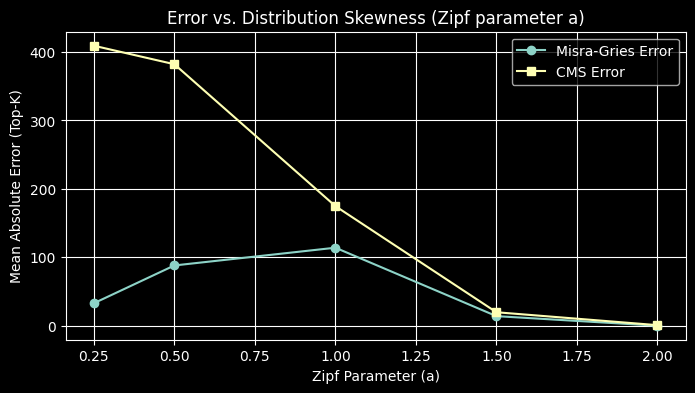

In [14]:
skews = [0.25, 0.5, 1, 1.5, 2.0]
mg_errors_skew = []
cms_errors_skew = []

print("Started Skewness Evaluation...")
for i, a in enumerate(skews):
    print(f"{i+1}/{len(skews)} Skewness: {a}")
    stream = sample_zipf_like(a, n=10000, size=100000)

    results = evaluate_algorithms(stream, mg_counters=500, cms_rows=5, cms_cols=200)
    mg_errors_skew.append(results["mg_mae"])
    cms_errors_skew.append(results["cms_mae"])

# plot (is generated by gemini)
plt.figure(figsize=(8, 4))
plt.plot(skews, mg_errors_skew, label='Misra-Gries Error', marker='o')
plt.plot(skews, cms_errors_skew, label='CMS Error', marker='s')
plt.title('Error vs. Distribution Skewness (Zipf parameter a)')
plt.xlabel('Zipf Parameter (a)')
plt.ylabel('Mean Absolute Error (Top-K)')
plt.legend()
plt.grid(True)
plt.show()

### Parameter sensitivity:
In this section, we evaluate the sensitivity of the Misra-Gries (MG) and Count-Min Sketch (CMS) algorithms to changes in their internal parameters. Using a stream generated from a moderately skewed distribution, we tracked multiple evaluation metrics across various total memory budgets. To maintain a fair evaluation for any given total space, MG was allocated a maximum number of counters equal to exactly half of the space budget (accounting for its two-word key-value storage). For CMS, we kept the total space strictly constant while varying the number of rows (hash functions), which inherently forced an inverse adjustment to the number of columns per row.

In [15]:
# parameters to test
rows_to_test = [2, 4, 5, 8, 10, 20]
total_space_to_test = [200, 1000, 10000, 1000000]

# trackers
cms_errs_rows = {ts: [] for ts in total_space_to_test}
cms_stds_rows = {ts: [] for ts in total_space_to_test}
mg_errs_space = {ts: [] for ts in total_space_to_test}

cms_time_rows = {ts: [] for ts in total_space_to_test}
cms_mem_rows = {ts: [] for ts in total_space_to_test}
mg_time_space = {ts: [] for ts in total_space_to_test}
mg_mem_space = {ts: [] for ts in total_space_to_test}

# Using a moderately skewed distribution
stream = sample_zipf_like(1, n=10000, size=1000000)

print("Running Hyperparameter Testing...")
for i, total_space in enumerate(total_space_to_test):
    for j, r in enumerate(rows_to_test):
        current_iter = (i * len(rows_to_test)) + j + 1
        print(f"{current_iter}/{len(rows_to_test)*len(total_space_to_test)} Currently parameters: total_spaces: {total_space} rows: {r}")
        c = total_space // r
        res = evaluate_algorithms(stream, mg_counters=total_space//2, cms_rows=r, cms_cols=c)

        cms_errs_rows[total_space].append(res["cms_mae"])
        cms_stds_rows[total_space].append(res["cms_std"])
        mg_errs_space[total_space].append(res["mg_mae"])

        cms_time_rows[total_space].append(res["cms_time"])
        cms_mem_rows[total_space].append(res["cms_memory_mb"])
        mg_time_space[total_space].append(res["mg_time"])
        mg_mem_space[total_space].append(res["mg_memory_mb"])

24/24 Currently parameters: total_spaces: 1000000 rows: 20


##### Plot the data
This part is AI generated using gemini.

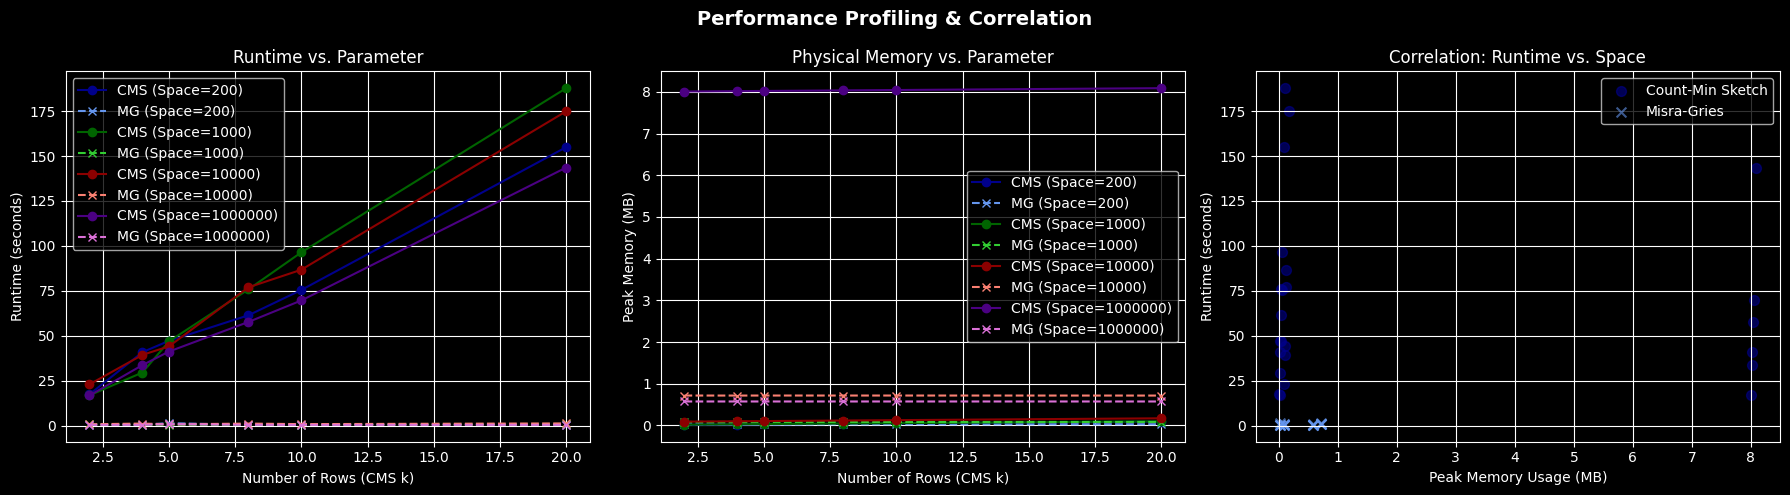

In [30]:
import matplotlib.pyplot as plt

colors = [
    'darkblue', 'cornflowerblue',  # Pair 1: Blues
    'darkgreen', 'limegreen',      # Pair 2: Greens
    'darkred', 'salmon',           # Pair 3: Reds
    'indigo', 'orchid'             # Pair 4: Purples
]

# ==========================================
# FIGURE 1: ACCURACY (Error & Standard Deviation)
# ==========================================
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for idx, ts in enumerate(total_space_to_test):
    # Select the paired colors based on the index
    cms_color = colors[(idx * 2) % len(colors)]      # Gets the Dark color (0, 2, 4)
    mg_color = colors[(idx * 2 + 1) % len(colors)]   # Gets the Light color (1, 3, 5)

    # MAE Plot
    ax1.plot(rows_to_test, cms_errs_rows[ts], marker='o', color=cms_color, label=f'CMS (Space={ts})')
    ax1.plot(rows_to_test, mg_errs_space[ts], marker='x', linestyle='--', color=mg_color, label=f'MG (Space={ts})')

    # StdDev Plot (CMS only)
    ax2.plot(rows_to_test, cms_stds_rows[ts], marker='s', color=cms_color, label=f'CMS (Space={ts})')

ax1.set(xlabel='Number of Rows (CMS k)', ylabel='Mean Absolute Error (Top-K)', title='Error Comparison')
ax2.set(xlabel='Number of Rows (CMS k)', ylabel='Standard Deviation', title='CMS Variance')
ax1.legend()
ax1.grid(True)
ax2.legend()
ax2.grid(True)
fig1.suptitle('Accuracy Sensitivity', fontsize=14, fontweight='bold')
fig1.tight_layout()

plt.show()
# ==========================================
# FIGURE 2: PERFORMANCE & CORRELATION
# ==========================================
fig2, (ax3, ax4, ax5) = plt.subplots(1, 3, figsize=(18, 5))

# Prepare lists for the scatter plot
all_cms_time, all_cms_mem = [], []
all_mg_time, all_mg_mem = [], []

for idx, ts in enumerate(total_space_to_test):
    # Select the paired colors based on the index
    cms_color = colors[(idx * 2) % len(colors)]
    mg_color = colors[(idx * 2 + 1) % len(colors)]

    # Plot 3: Runtime vs Rows
    ax3.plot(rows_to_test, cms_time_rows[ts], marker='o', color=cms_color, label=f'CMS (Space={ts})')
    ax3.plot(rows_to_test, mg_time_space[ts], marker='x', linestyle='--', color=mg_color, label=f'MG (Space={ts})')

    # Plot 4: Memory vs Rows
    ax4.plot(rows_to_test, cms_mem_rows[ts], marker='o', color=cms_color, label=f'CMS (Space={ts})')
    ax4.plot(rows_to_test, mg_mem_space[ts], marker='x', linestyle='--', color=mg_color, label=f'MG (Space={ts})')

    # Accumulate data for scatter plot
    all_cms_time.extend(cms_time_rows[ts])
    all_cms_mem.extend(cms_mem_rows[ts])
    all_mg_time.extend(mg_time_space[ts])
    all_mg_mem.extend(mg_mem_space[ts])

ax3.set(xlabel='Number of Rows (CMS k)', ylabel='Runtime (seconds)', title='Runtime vs. Parameter')
ax4.set(xlabel='Number of Rows (CMS k)', ylabel='Peak Memory (MB)', title='Physical Memory vs. Parameter')
ax3.legend()
ax3.grid(True)
ax4.legend()
ax4.grid(True)

# Plot 5: Correlation (Scatter Plot)
# We can use static colors here since it plots all points at once regardless of space
ax5.scatter(all_cms_mem, all_cms_time, color='darkblue', alpha=0.6, marker='o', s=50, label='Count-Min Sketch')
ax5.scatter(all_mg_mem, all_mg_time, color='cornflowerblue', alpha=0.6, marker='x', s=50, label='Misra-Gries')

ax5.set(xlabel='Peak Memory Usage (MB)', ylabel='Runtime (seconds)', title='Correlation: Runtime vs. Space')
ax5.legend()
ax5.grid(True)

fig2.suptitle('Performance Profiling & Correlation', fontsize=14, fontweight='bold')
fig2.tight_layout()

# A single plt.show() at the very end renders all active figures at once
plt.show()